In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

snaps = pd.read_csv("data/snapshots.csv", parse_dates=["resolved_at"])
HORIZONS = sorted(snaps["horizon_days"].unique())

print(snaps.groupby("horizon_days").agg(
    n=("outcome", "size"),
    markets=("market_id", "nunique"),
    events=("event_id", "nunique"),
    yes_rate=("outcome", "mean"),
))

                n  markets  events  yes_rate
horizon_days                                
1             375      375     233  0.458667
3             265      265     163  0.422642
7             213      213     128  0.389671
14            183      183     105  0.349727
30            140      140      80  0.335714


In [20]:
def wilson_ci(k, n, z=1.96):
    """95% Wilson confidence interval for k successes in n trials."""
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return center - half, center + half

def calibration_table(df, n_bins=10):
    df = df.copy()
    df["bin"] = pd.qcut(df["price"], q=n_bins, duplicates="drop")
    t = df.groupby("bin", observed=True).agg(
        n=("outcome", "size"),
        wins=("outcome", "sum"),
        avg_price=("price", "mean"),
    )
    t["win_rate"] = t["wins"] / t["n"]
    lo, hi = wilson_ci(t["wins"], t["n"])
    # Floating-point error can put the bounds a hair outside [0, 1] or past
    # win_rate when win_rate is exactly 0 or 1. Clamp so the interval is valid.
    t["ci_lo"] = np.minimum(np.clip(lo, 0, 1), t["win_rate"])
    t["ci_hi"] = np.maximum(np.clip(hi, 0, 1), t["win_rate"])
    t["gap"] = t["win_rate"] - t["avg_price"]   # > 0: happens more often than priced
    return t

calibration_table(snaps[snaps["horizon_days"] == 7])

,n,wins,avg_price,win_rate,ci_lo,ci_hi,gap
bin,,,,,,,
"(-0.0005, 0.008]",23,0,0.005000,0.000000,0.000000,0.143121,-0.005000
"(0.008, 0.015]",21,0,0.011905,0.000000,0.000000,0.154644,-0.011905
"(0.015, 0.029]",20,0,0.021050,0.000000,0.000000,0.161130,-0.021050
"(0.029, 0.082]",21,2,0.045810,0.095238,0.026518,0.289146,0.049429
"(0.082, 0.23]",22,3,0.145682,0.136364,0.047489,0.333354,-0.009318
"(0.23, 0.45]",22,10,0.335455,0.454545,0.269200,0.653405,0.119091
"(0.45, 0.522]",20,10,0.495250,0.500000,0.299295,0.700705,0.004750
"(0.522, 0.793]",21,17,0.662619,0.809524,0.599990,0.923326,0.146905
"(0.793, 0.929]",21,19,0.857333,0.904762,0.710854,0.973482,0.047429


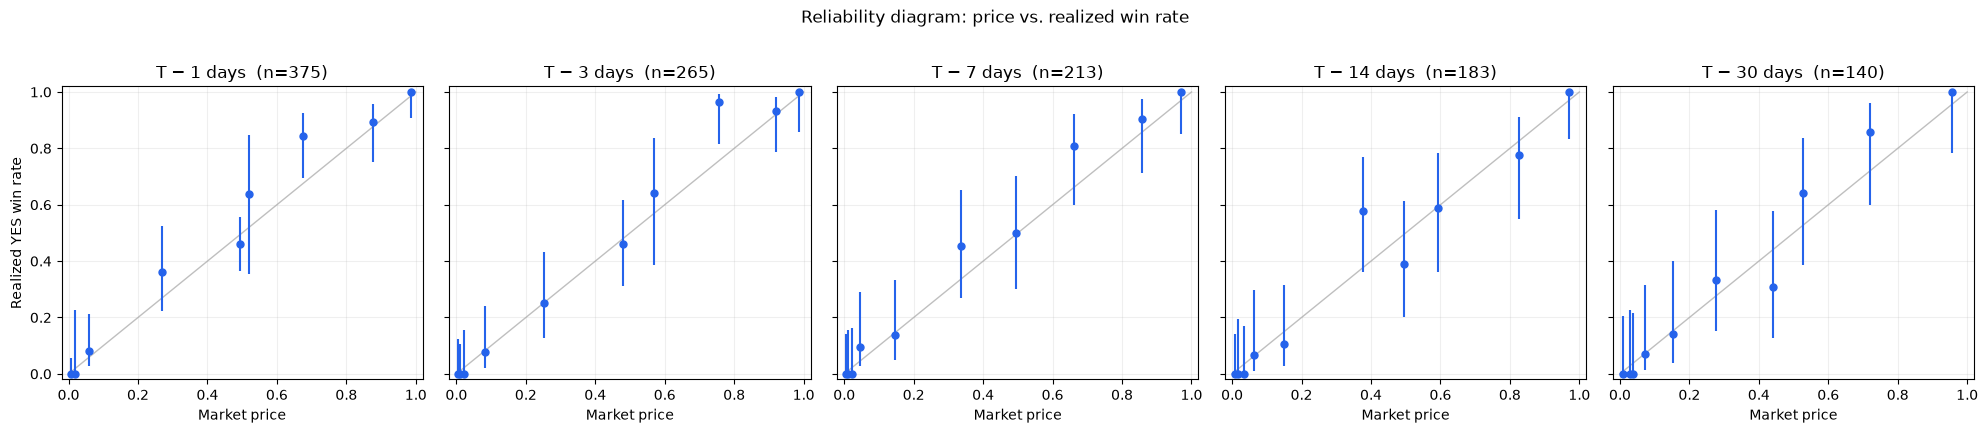

In [21]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(4 * len(HORIZONS), 4.2),
                         sharex=True, sharey=True)

for ax, h in zip(axes, HORIZONS):
    t = calibration_table(snaps[snaps["horizon_days"] == h])
    yerr = np.clip(
        np.vstack([t["win_rate"] - t["ci_lo"], t["ci_hi"] - t["win_rate"]]),
        0, None,
    )
    ax.plot([0, 1], [0, 1], color="0.75", lw=1, zorder=0)   # perfect calibration
    ax.errorbar(t["avg_price"], t["win_rate"], yerr=yerr,
                fmt="o", ms=5, lw=1.5, capsize=0, color="#2563eb")
    ax.set_title(f"T − {h} days  (n={int(t['n'].sum())})")
    ax.set_xlabel("Market price")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Realized YES win rate")
fig.suptitle("Reliability diagram: price vs. realized win rate", y=1.02)
plt.tight_layout()

In [22]:
def brier_decomposition(df, n_bins=10):
    y, p = df["outcome"].values, df["price"].values
    brier = np.mean((p - y) ** 2)
    ybar = y.mean()

    t = calibration_table(df, n_bins)
    w = t["n"] / t["n"].sum()
    rel = np.sum(w * (t["avg_price"] - t["win_rate"]) ** 2)
    res = np.sum(w * (t["win_rate"] - ybar) ** 2)
    unc = ybar * (1 - ybar)

    return pd.Series({
        "n": len(df), "brier": brier, "REL": rel, "RES": res, "UNC": unc,
        "BSS": 1 - brier / unc,
    })

snaps.groupby("horizon_days").apply(brier_decomposition).round(4)

,n,brier,REL,RES,UNC,BSS
horizon_days,,,,,,
1,375.0,0.1284,0.0045,0.1228,0.2483,0.4827
3,265.0,0.0866,0.0048,0.1598,0.2440,0.6451
7,213.0,0.0963,0.0042,0.1444,0.2378,0.5951
14,183.0,0.1059,0.0060,0.1244,0.2274,0.5344
30,140.0,0.0983,0.0057,0.1253,0.2230,0.5594


In [23]:
counts = snaps.groupby("market_id")["horizon_days"].nunique()
full_markets = counts[counts == len(HORIZONS)].index
balanced = snaps[snaps["market_id"].isin(full_markets)]

print(f"all horizon: {len(full_markets)}")
balanced.groupby("horizon_days").apply(brier_decomposition).round(4)

all horizon: 139


,n,brier,REL,RES,UNC,BSS
horizon_days,,,,,,
1,139.0,0.0471,0.0026,0.1764,0.2214,0.7872
3,139.0,0.0471,0.0034,0.1752,0.2214,0.7874
7,139.0,0.0595,0.0033,0.1539,0.2214,0.7315
14,139.0,0.0773,0.0031,0.1477,0.2214,0.6509
30,139.0,0.0988,0.0061,0.1216,0.2214,0.5540


In [24]:
h7 = snaps[snaps["horizon_days"] == 7].copy()
h7["vol_group"] = pd.qcut(h7["volume"], q=3, labels=["low vol", "mid vol", "high vol"])

print(h7.groupby("vol_group", observed=True)["volume"].agg(["min", "median", "max"]).round(0))
h7.groupby("vol_group", observed=True).apply(brier_decomposition, n_bins=5).round(4)

               min   median        max
vol_group                             
low vol     1015.0   2914.0     6396.0
mid vol     6778.0  13695.0    34368.0
high vol   35103.0  97673.0  8828319.0


,n,brier,REL,RES,UNC,BSS
vol_group,,,,,,
low vol,71.0,0.1070,0.0069,0.1205,0.2281,0.5308
mid vol,71.0,0.0833,0.0120,0.1622,0.2357,0.6464
high vol,71.0,0.0985,0.0292,0.1574,0.2460,0.5995


In [25]:
print("category missing:", h7["category"].isna().mean().round(3))
print(h7["category"].value_counts().head(10))

h7.groupby("neg_risk").apply(brier_decomposition, n_bins=5).round(4)

category missing: 0.925
category
US-current-affairs    15
Crypto                 1
Name: count, dtype: int64


,n,brier,REL,RES,UNC,BSS
neg_risk,,,,,,
False,213.0,0.0963,0.0022,0.1337,0.2378,0.5951


In [26]:
calib_by_h = pd.concat(
    {h: calibration_table(snaps[snaps["horizon_days"] == h]) for h in HORIZONS},
    names=["horizon_days"],
)
calib_by_h.to_csv("data/calibration_by_horizon.csv")
snaps.groupby("horizon_days").apply(brier_decomposition).to_csv("data/brier_by_horizon.csv")
fig.savefig("data/reliability_diagram.png", dpi=150, bbox_inches="tight")